---
#### Import All Libraries

In [82]:
# IMPORTS 
# pandas       → data loading, manipulation, groupby operations
# numpy        → numerical computation, log transforms, IQR math
# matplotlib   → all charts and visualisations
# seaborn      → statistical plots (heatmap, boxplot, violin)
# hashlib      → SHA-256 UUID for anonymisation (privacy layer)
# re           → regex for PII scrubbing from comments
# warnings     → suppress minor sklearn/pandas warnings for clean output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import hashlib
import re
import warnings
warnings.filterwarnings('ignore')

# Chart styling — consistent across all plots in this notebook
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
sns.set_palette("husl")

import os
os.makedirs('../data',   exist_ok=True)
os.makedirs('../charts', exist_ok=True)

print(" All libraries imported")



 All libraries imported


---
## Cell 2 — Load Raw Dataset

In [83]:
#  LOAD DATASET 

RAW_PATH = "../data/RateMyProfessor_Sample data.csv"
df_raw   = pd.read_csv(RAW_PATH)

print("=" * 60)
print("  RAW DATASET — INITIAL SNAPSHOT")
print("=" * 60)
print(f"  Total rows    : {df_raw.shape[0]:,}")
print(f"  Total columns : {df_raw.shape[1]}")
print("=" * 60)
print()
print("Preview (first 3 rows):")
display(df_raw.head(3))


  RAW DATASET — INITIAL SNAPSHOT
  Total rows    : 20,000
  Total columns : 51

Preview (first 3 rows):


,professor_name,school_name,department_name,local_name,state_name,year_since_first_review,star_rating,take_again,diff_index,tag_professor,...,lots_of_homework,accessible_outside_class,lecture_heavy,extra_credit,graded_by_few_things,group_projects,test_heavy,so_many_papers,beware_of_pop_quizzes,IsCourseOnline
0,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
1,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0
2,Leslie Looney,University Of Illinois at Urbana-Champaign,Astronomy department,Champaign\xe2\x80\x93Urbana,IL,11,4.7,NaN,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,0,0,0,0,0,1,0,0,0,0


---
#### Full Column Audit

In [84]:
# ─── CELL 3: COLUMN AUDIT ───────────────────────────────────────────────────
# Before touching the data, we audit EVERY column.
# For each column we document: dtype, missing %, and DECISION (keep/drop).
# This audit is our official record of why each column was handled.

print(f"{'#':<4} {'Column':<35} {'Type':<12} {'Nulls':>6} {'Miss%':>6}  Decision")
print("─" * 85)

col_decisions = {
    # PII — drop (project privacy layer requires this)
    'professor_name'    : ('DROP',  'PII — direct identifier'),
    'school_name'       : ('DROP',  'PII — institutional identifier'),
    'local_name'        : ('DROP',  'US city — irrelevant to Indian project'),
    'state_name'        : ('DROP',  'US state — irrelevant to Indian project'),
    'name_onlines'      : ('DROP',  'Name variant field — PII'),
    'name_not_onlines'  : ('DROP',  'Name variant field — PII'),
    # >80% missing — cannot be reliably filled
    'take_again'        : ('DROP',  '85.0% missing — unfillable'),
    'would_take_agains' : ('DROP',  '87.1% missing — unfillable'),
    'grades'            : ('DROP',  '83.5% missing — unfillable'),
    'attence'           : ('DROP',  '80.0% missing — unfillable'),
    'for_credits'       : ('DROP',  '79.7% missing — unfillable'),
    # Redundant / low signal
    
    'race'              : ('DROP',  'Demographic — not used in NLP pipeline'),
    'asian'             : ('DROP',  'Race proportion — not used'),
    'hispanic'          : ('DROP',  'Race proportion — not used'),
    'nh_black'          : ('DROP',  'Race proportion — not used'),
    'nh_white'          : ('DROP',  'Race proportion — not used'),
    'gender'            : ('DROP',  'Mostly unknown — low signal for NLP task'),
    # KEEP — core signal
    'student_star'      : ('KEEP',  'TARGET LABEL for sentiment model'),
    'star_rating'       : ('KEEP',  'Aggregated rating — key feature'),
    'diff_index'        : ('KEEP',  'Difficulty signal — key feature'),
    'student_difficult' : ('KEEP',  'Per-review difficulty perception'),
    'comments'          : ('KEEP',  'NLP INPUT — core text for sentiment model'),
    'word_comment'      : ('KEEP',  'Comment length feature'),
    'IsCourseOnline'    : ('KEEP',  'Delivery mode feature'),
    'year_since_first_review': ('KEEP', 'Professor experience proxy'),
    'num_student'       : ('KEEP',  'Review volume indicator'),
    'post_date'         : ('KEEP',  'Time-based trend feature'),
    'help_useful'       : ('KEEP',  'Peer helpfulness signal'),
    'help_not_useful'   : ('KEEP',  'Peer helpfulness signal'),
}
# All 20 tag columns → KEEP
tags = ['gives_good_feedback','tag_professor','caring','respected','participation_matters',
        'clear_grading_criteria','skip_class','amazing_lectures','inspirational',
        'tough_grader','hilarious','get_ready_to_read','lots_of_homework',
        'accessible_outside_class','lecture_heavy','extra_credit',
        'graded_by_few_things','group_projects','test_heavy',
        'so_many_papers','beware_of_pop_quizzes']
for t in tags:
    col_decisions[t] = ('KEEP', 'Binary tag — structured sentiment signal')

keep_count = drop_count = 0
for i, col in enumerate(df_raw.columns, 1):
    nulls = df_raw[col].isnull().sum()
    pct   = nulls / len(df_raw) * 100
    dec, reason = col_decisions.get(col, ('KEEP', 'Default keep'))
    marker = '✓' if dec == 'KEEP' else '✗'
    color  = ''
    print(f"{i:<4} {col:<35} {str(df_raw[col].dtype):<12} {nulls:>6,} {pct:>5.1f}%  {marker} {dec} — {reason}")
    if dec == 'KEEP': keep_count += 1
    else: drop_count += 1

print()
print(f"  Total KEEP : {keep_count}")
print(f"  Total DROP : {drop_count}")
print(f"  51 → {keep_count} columns after cleaning")


#    Column                              Type          Nulls  Miss%  Decision
─────────────────────────────────────────────────────────────────────────────────────
1    professor_name                      str               0   0.0%  ✗ DROP — PII — direct identifier
2    school_name                         str               0   0.0%  ✗ DROP — PII — institutional identifier
3    department_name                     str               0   0.0%  ✓ KEEP — Default keep
4    local_name                          str               0   0.0%  ✗ DROP — US city — irrelevant to Indian project
5    state_name                          str               0   0.0%  ✗ DROP — US state — irrelevant to Indian project
6    year_since_first_review             int64             0   0.0%  ✓ KEEP — Professor experience proxy
7    star_rating                         float64           0   0.0%  ✓ KEEP — Aggregated rating — key feature
8    take_again                          str          17,002  85.0%  ✗ DROP — 85.0% 

---
#### Drop PII Columns


In [85]:
# ─── CELL 4: DROP PII COLUMNS ──────────────────────────────────────────────
# The EDU-FEED pipeline document states:
#   "No student name, ID, roll number, email, section, or batch is ever
#    stored or passed to any model."
# For the RMP dataset, the equivalent PII is:
#   professor_name, school_name, local_name, state_name, name_onlines,
#   name_not_onlines
# These are also irrelevant to the Indian educational context.

df = df_raw.copy()

PII_COLS = ['professor_name', 'school_name', 'local_name',
            'state_name', 'name_onlines', 'name_not_onlines']

print("Dropping PII columns:")
for col in PII_COLS:
    sample = df[col].iloc[0]
    print(f"  {col:<25} (sample: {str(sample)[:40]})")

df = df.drop(columns=PII_COLS)
print(f"\nShape after PII drop: {df.shape}  (was 51 → now {df.shape[1]} columns)")


Dropping PII columns:
  professor_name            (sample: Leslie  Looney)
  school_name               (sample: University Of Illinois at Urbana-Champai)
  local_name                (sample:  Champaign\xe2\x80\x93Urbana)
  state_name                (sample:  IL)
  name_onlines              (sample: NAN)
  name_not_onlines          (sample: ASTR122)

Shape after PII drop: (20000, 45)  (was 51 → now 45 columns)


---
#### Drop High-Missing Columns
*Filling >80% of a column with imputed values means fabricating data — that introduces bias into the model.*

Columns with >79% missing values:
---------------------------------------------
  would_take_agains            87.1% missing
  take_again                   85.0% missing
  grades                       83.5% missing
  attence                      80.0% missing
  for_credits                  79.7% missing


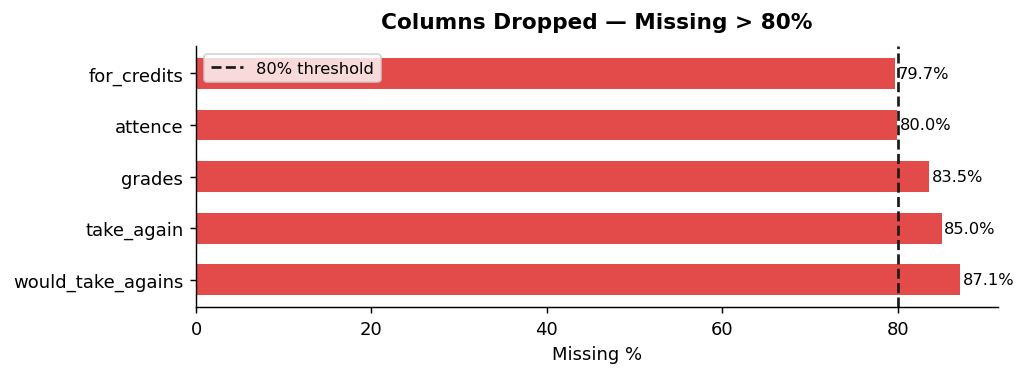


Dropped 5 columns
Shape: (20000, 40)


In [86]:
#DROP HIGH-MISSING COLUMNS 
# Decision rule: if a column has >80% null values, DROP it.
# Rationale: imputing 80%+ means we are inventing 16,000+ values.
# Any model trained on such a column learns from our fabrication, not data.

missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 79].sort_values(ascending=False)

print("Columns with >79% missing values:")
print("-" * 45)
for col, pct in high_missing.items():
    print(f"  {col:<28} {pct:.1f}% missing")

# Visualise
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(high_missing.index, high_missing.values,
        color='#E24B4A', height=0.6, edgecolor='none')
ax.axvline(80, color='#1a1a18', linestyle='--', linewidth=1.5,
           label='80% threshold')
for i, (col, val) in enumerate(high_missing.items()):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Columns Dropped — Missing > 80%', fontweight='bold', pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../charts/01_high_missing_cols.png', dpi=150, bbox_inches='tight')
plt.show()

df = df.drop(columns=high_missing.index.tolist())
print(f"\nDropped {len(high_missing)} columns")
print(f"Shape: {df.shape}")


---
####  Drop Irrelevant / Low-Signal Columns
*Demographics not used in the NLP pipeline. tag_professor is 44% missing and its signal is already captured by the 20 structured binary tag columns.*

In [87]:
# ─── CELL 6: DROP IRRELEVANT COLUMNS ────────────────────────────────────────
# Columns dropped and why:
# gender          : mostly 'unknown'. Not used anywhere in the NLP or clustering
#                   pipeline described in the project document.
# race            : not used in any model in the pipeline.
# asian/hispanic/nh_black/nh_white : race proportion columns. Same reason.

IRRELEVANT_COLS = [ 'gender', 'race',
                   'asian', 'hispanic', 'nh_black', 'nh_white']

print("Dropping irrelevant/low-signal columns:")
for col in IRRELEVANT_COLS:
    if col in df.columns:
        miss = df[col].isnull().sum()
        print(f"  {col:<28} (nulls: {miss:,})")

df = df.drop(columns=[c for c in IRRELEVANT_COLS if c in df.columns])
print(f"\nShape: {df.shape}")
print(f"\nRemaining columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


Dropping irrelevant/low-signal columns:
  gender                       (nulls: 0)
  race                         (nulls: 0)
  asian                        (nulls: 0)
  hispanic                     (nulls: 0)
  nh_black                     (nulls: 0)
  nh_white                     (nulls: 0)

Shape: (20000, 34)

Remaining columns (34):
   1. department_name
   2. year_since_first_review
   3. star_rating
   4. diff_index
   5. tag_professor
   6. num_student
   7. post_date
   8. student_star
   9. student_difficult
  10. help_useful
  11. help_not_useful
  12. comments
  13. word_comment
  14. gives_good_feedback
  15. caring
  16. respected
  17. participation_matters
  18. clear_grading_criteria
  19. skip_class
  20. amazing_lectures
  21. inspirational
  22. tough_grader
  23. hilarious
  24. get_ready_to_read
  25. lots_of_homework
  26. accessible_outside_class
  27. lecture_heavy
  28. extra_credit
  29. graded_by_few_things
  30. group_projects
  31. test_heavy
  32. so_many_pa

---
#### Remove Duplicate Rows


In [88]:
# REMOVE DUPLICATES 
# Strategy: drop all rows that are IDENTICAL across all remaining columns.
# An exact duplicate means the same review was submitted twice — this should
# not happen and indicates a data collection error.

before = len(df)
df     = df.drop_duplicates()
after  = len(df)

print(f"Rows before deduplication : {before:,}")
print(f"Duplicate rows found      : {before - after}")
print(f"Rows after deduplication  : {after:,}")
print(f"\n Dataset is now free of exact duplicates")


Rows before deduplication : 20,000
Duplicate rows found      : 23
Rows after deduplication  : 19,977

 Dataset is now free of exact duplicates


---
#### Null Value Analysis & Treatment

Remaining null values after column drops:
-------------------------------------------------------
  tag_professor                  8891 nulls  (44.506%)
  post_date                         1 nulls  (0.005%)
  student_star                      1 nulls  (0.005%)
  student_difficult                 1 nulls  (0.005%)
  comments                          3 nulls  (0.015%)
  word_comment                      3 nulls  (0.015%)


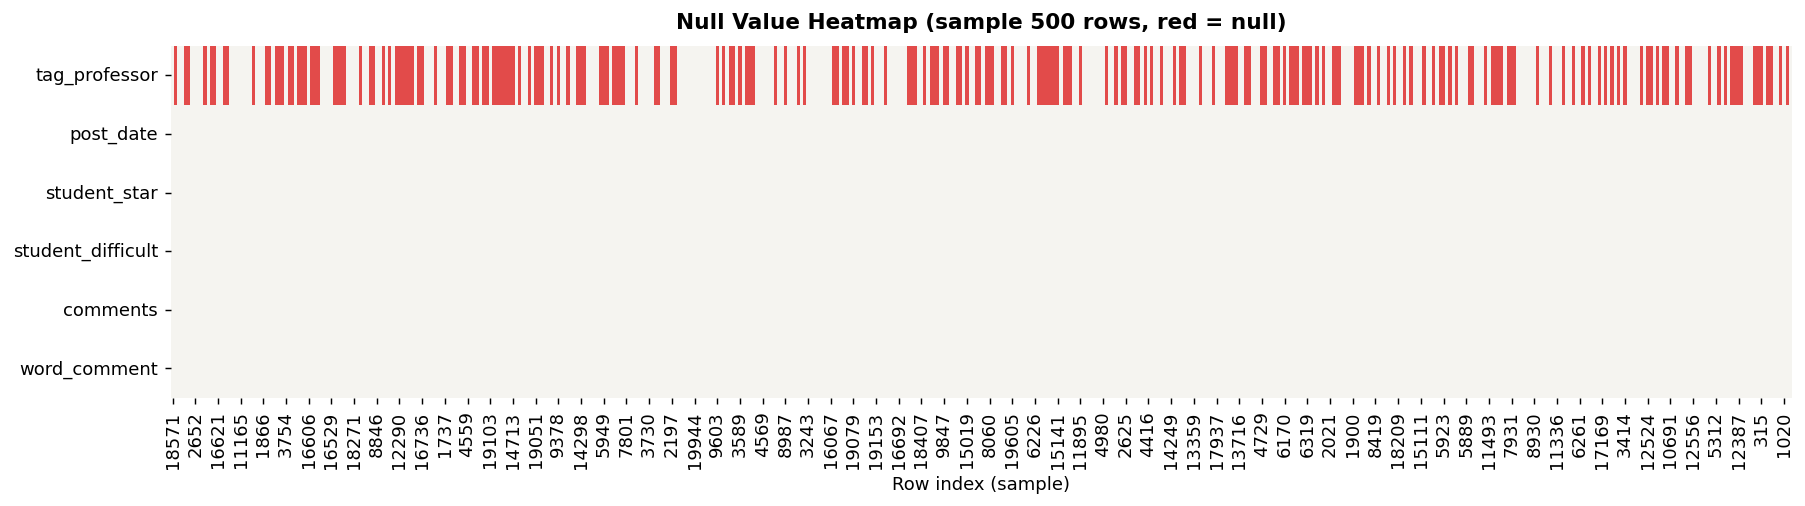

In [89]:
# CELL 8: NULL ANALYSIS
# After dropping high-missing columns, we check what nulls remain.
# These are all small (< 0.1% of rows) and safe to impute.

remaining_nulls = df.isnull().sum()
has_nulls = remaining_nulls[remaining_nulls > 0]

print("Remaining null values after column drops:")
print("-" * 55)
if len(has_nulls) == 0:
    print("  No nulls — dataset is already clean!")
else:
    for col, cnt in has_nulls.items():
        pct = cnt / len(df) * 100
        print(f"  {col:<30} {cnt:>4} nulls  ({pct:.3f}%)")

# Visualise null heatmap of all remaining columns
fig, ax = plt.subplots(figsize=(14, 4))
null_matrix = df.isnull().astype(int)
# Show only cols with any nulls
null_cols = null_matrix.columns[null_matrix.any()]
if len(null_cols) > 0:
    sample_idx = np.random.choice(len(df), size=min(500, len(df)), replace=False)
    sns.heatmap(null_matrix.iloc[sample_idx][null_cols].T,
                cmap=['#f5f4f0','#E24B4A'], cbar=False, ax=ax,
                yticklabels=null_cols)
    ax.set_title('Null Value Heatmap (sample 500 rows, red = null)',
                 fontweight='bold', pad=10)
    ax.set_xlabel('Row index (sample)')
    plt.tight_layout()
    plt.savefig('../charts/02_null_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\n  No null heatmap needed — no remaining nulls in key columns")


In [90]:
# FILL REMAINING NULLS 
#   student_star, student_difficult, word_comment
#     → fill with MEDIAN (not mean, because ratings can be skewed)
#     → median is robust: it is the middle value, not pulled by extremes
#   post_date → fill with 'Unknown'
#     → prevents errors when we later parse dates
#   comments  → fill with empty string ''
#     → an empty string is valid NLP input (model sees no tokens)
#   name_not_onlines → already dropped (was PII)

df = df.assign(
    tag_professor     = df['tag_professor'].fillna('NoTag'),
    student_star      = df['student_star'].fillna(df['student_star'].median()),
    student_difficult = df['student_difficult'].fillna(df['student_difficult'].median()),
    word_comment      = df['word_comment'].fillna(df['word_comment'].median()),
    post_date         = df['post_date'].fillna('Unknown'),
    comments          = df['comments'].fillna('')
)

# Confirm no nulls remain in any column we use
remaining = df.isnull().sum()
still_null = remaining[remaining > 0]

print("After null treatment:")
if len(still_null) == 0:
    print("   Zero nulls in all columns")
else:
    print(still_null)

print(f"\nFinal shape after null treatment: {df.shape}")


After null treatment:
   Zero nulls in all columns

Final shape after null treatment: (19977, 34)


---
#### Outlier Detection (IQR Method)
*We detect outliers using the IQR fence method. Then we judge each case: is it a data error (fix it) or a legitimate extreme value (keep or cap)?*

In [91]:
# ─── CELL 9: OUTLIER DETECTION ──────────────────────────────────────────────
# IQR METHOD:
#   Q1 = 25th percentile, Q3 = 75th percentile
#   IQR = Q3 - Q1
#   Lower fence = Q1 - 1.5 × IQR
#   Upper fence = Q3 + 1.5 × IQR
#   Any value outside these fences = statistical outlier
#
# KEY INSIGHT: IQR flagging ≠ automatically remove.
# We must decide PER COLUMN whether flagged values are:
#   (a) DATA ERRORS       → remove or replace
#   (b) LEGITIMATE EXTREMES → cap (winsorize) or transform
#   (c) FALSE ALARM (zero-inflated or bounded scale) → keep as-is

NUMERIC_COLS = ['star_rating', 'student_star', 'student_difficult',
                'diff_index', 'num_student', 'help_useful',
                'help_not_useful', 'word_comment', 'year_since_first_review']

print(f"{'Column':<30} {'Min':>5} {'Max':>5} {'Median':>7} {'IQR':>6} "
      f"{'Outliers':>9} {'%':>6}  Verdict")
print("─" * 105)

outlier_info = {}
for col in NUMERIC_COLS:
    s   = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = s[(s < lo) | (s > hi)]
    pct = len(out)/len(s)*100

    # Determine verdict
    if col in ['star_rating','student_star','student_difficult','diff_index']:
        verdict = " Bounded 1-5 scale — IQR false alarm, KEEP"
    elif col == 'num_student':
        verdict = " Legit extremes — CAP at 99th percentile"
    elif col in ['help_useful','help_not_useful']:
        verdict = " Zero-inflated — LOG(x+1) transform"
    elif col == 'word_comment':
        verdict = " Single extreme (long review) — KEEP"
    elif col == 'year_since_first_review':
        verdict = " Valid range 0-16 — KEEP"
    else:
        verdict = " OK"

    outlier_info[col] = dict(Q1=Q1, Q3=Q3, IQR=IQR, lo=lo, hi=hi,
                              n_out=len(out), pct=pct, verdict=verdict)

    print(f"{col:<30} {s.min():>5.1f} {s.max():>5.1f} {s.median():>7.2f} "
          f"{IQR:>6.2f} {len(out):>9,} {pct:>5.1f}%  {verdict}")


Column                           Min   Max  Median    IQR  Outliers      %  Verdict
─────────────────────────────────────────────────────────────────────────────────────────────────────────
star_rating                      1.0   5.0    3.70   1.30        20   0.1%   Bounded 1-5 scale — IQR false alarm, KEEP
student_star                     1.0   5.0    4.00   2.50         0   0.0%   Bounded 1-5 scale — IQR false alarm, KEEP
student_difficult                1.0   5.0    3.00   2.00         0   0.0%   Bounded 1-5 scale — IQR false alarm, KEEP
diff_index                       1.0   5.0    3.00   1.10         0   0.0%   Bounded 1-5 scale — IQR false alarm, KEEP
num_student                      1.0 321.0   24.00  26.00     1,439   7.2%   Legit extremes — CAP at 99th percentile
help_useful                      0.0   9.0    0.00   0.00     3,350  16.8%   Zero-inflated — LOG(x+1) transform
help_not_useful                  0.0   9.0    0.00   0.00     2,094  10.5%   Zero-inflated — LOG(x+1) tra

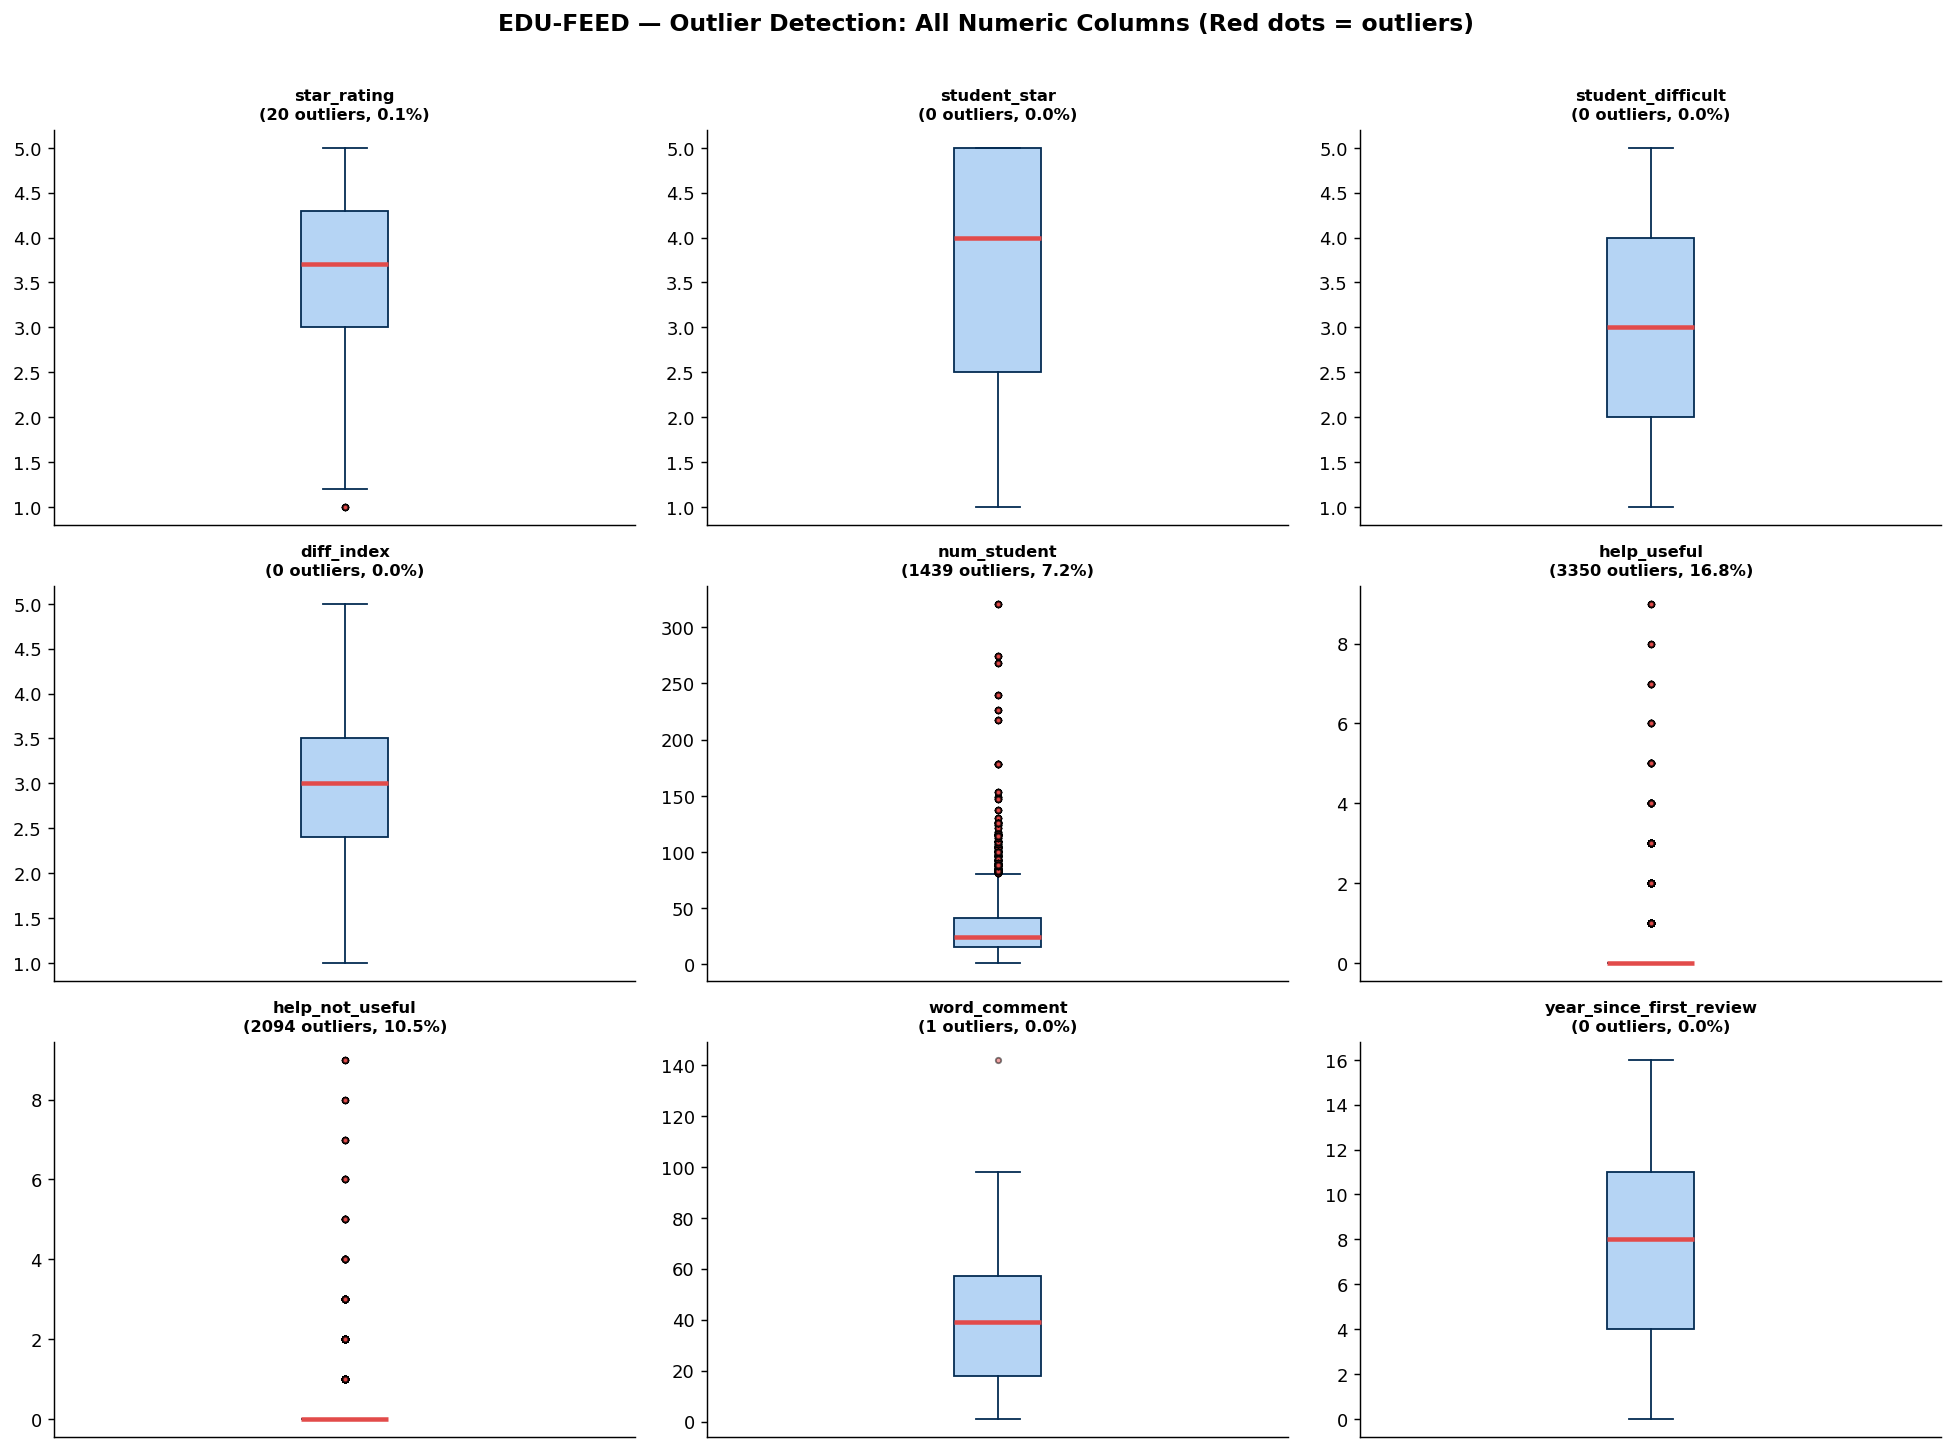

 Saved → charts/03_outlier_boxplots.png


In [92]:
#  OUTLIER BOXPLOTS 
# Visualise distributions and outliers side by side so the team can SEE
# the shape of each column and confirm our treatment decisions.

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((s < lo) | (s > hi)).sum()

    axes[i].boxplot(s, vert=True, patch_artist=True,
        boxprops=dict(facecolor='#B5D4F4', color='#042C53', linewidth=1),
        medianprops=dict(color='#E24B4A', linewidth=2.5),
        whiskerprops=dict(color='#042C53'),
        capprops=dict(color='#042C53'),
        flierprops=dict(marker='o', markerfacecolor='#E24B4A',
                        markersize=3, alpha=0.5, linestyle='none'))
    axes[i].set_title(f'{col}\n({n_out} outliers, {n_out/len(s)*100:.1f}%)',
                      fontsize=9, fontweight='bold', pad=6)
    axes[i].set_xticks([])

plt.suptitle('EDU-FEED — Outlier Detection: All Numeric Columns (Red dots = outliers)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/03_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → charts/03_outlier_boxplots.png")


---
#### Outlier Treatment
We apply the correct fix to each outlier situation 

In [93]:
#  OUTLIER TREATMENT 

# ┌─────────────────────┬──────────────────────┬────────────────────────────────┐
# │ Column              │ Treatment            │ Reason                         │
# ├─────────────────────┼──────────────────────┼────────────────────────────────┤
# │ star_rating         │ KEEP                 │ Bounded 1-5 scale. IQR is a    │
# │ student_star        │ KEEP                 │ false alarm on narrow scales.  │
# │ student_difficult   │ KEEP                 │ A value of 1.0 or 5.0 is VALID │
# │ diff_index          │ KEEP                 │ data, not an error.            │
# ├─────────────────────┼──────────────────────┼────────────────────────────────┤
# │ num_student         │ CAP at 99th pct      │ Some professors have 300+ stud-│
# │                     │ (Winsorization)      │ ents legitimately. But extreme │
# │                     │                      │ values give those professors   │
# │                     │                      │ disproportionate model weight. │
# ├─────────────────────┼──────────────────────┼────────────────────────────────┤
# │ help_useful         │ LOG(x+1)             │ 83% of rows = 0. Q3=0, IQR=0.  │
# │ help_not_useful     │ LOG(x+1)             │ IQR flags every non-zero value │
# │                     │                      │ as "outlier" — it's a FALSE    │
# │                     │                      │ ALARM from zero-inflation.     │
# │                     │                      │ log(x+1) compresses the scale  │
# │                     │                      │ and makes it usable.           │
# ├─────────────────────┼──────────────────────┼────────────────────────────────┤
# │ word_comment        │ KEEP                 │ 1 extreme value (142 words).   │
# │ year_since_first_   │ KEEP                 │ Valid range 0-16. No action.   │
# └─────────────────────┴──────────────────────┴────────────────────────────────┘

# Treatment 1: Cap num_student at 99th percentile 
cap_value = df['num_student'].quantile(0.99)
n_capped  = (df['num_student'] > cap_value).sum()
df['num_student'] = df['num_student'].clip(upper=cap_value)
print(f" num_student  → capped at {cap_value:.0f} (99th pct)  [{n_capped} rows affected]")
print(f"  Before: max = {df_raw['num_student'].max():.0f}")
print(f"  After : max = {df['num_student'].max():.0f}")

#  Treatment 2: Log(x+1) for zero-inflated help columns 
# We create NEW columns and keep originals for documentation purposes.
df['help_useful_log']     = np.log1p(df['help_useful'])
df['help_not_useful_log'] = np.log1p(df['help_not_useful'])
print(f"\n help_useful         → log(x+1) → 'help_useful_log' created")
print(f"  Before: mean={df['help_useful'].mean():.2f}  std={df['help_useful'].std():.2f}")
print(f"  After : mean={df['help_useful_log'].mean():.2f}  std={df['help_useful_log'].std():.2f}")
print(f"\n help_not_useful     → log(x+1) → 'help_not_useful_log' created")
print(f"  Before: mean={df['help_not_useful'].mean():.2f}  std={df['help_not_useful'].std():.2f}")
print(f"  After : mean={df['help_not_useful_log'].mean():.2f}  std={df['help_not_useful_log'].std():.2f}")


 num_student  → capped at 147 (99th pct)  [200 rows affected]
  Before: max = 321
  After : max = 147

 help_useful         → log(x+1) → 'help_useful_log' created
  Before: mean=0.29  std=0.86
  After : mean=0.16  std=0.38

 help_not_useful     → log(x+1) → 'help_not_useful_log' created
  Before: mean=0.19  std=0.72
  After : mean=0.10  std=0.31


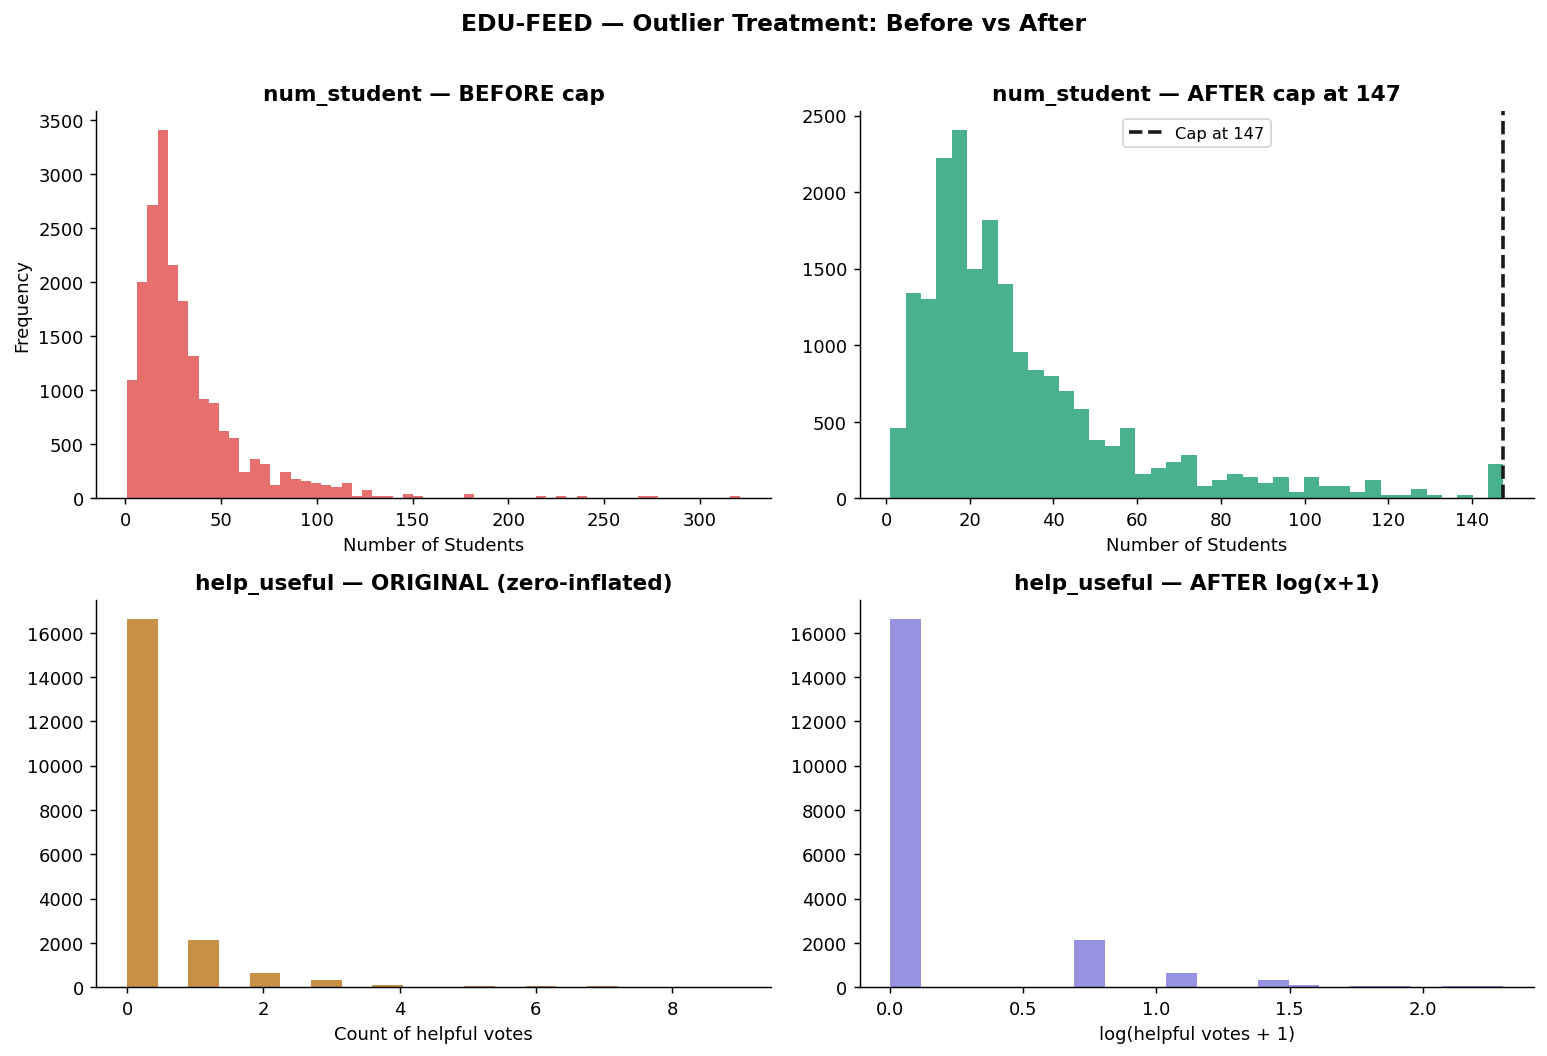

 Saved → charts/04_outlier_treatment.png


In [94]:
#  BEFORE vs AFTER VISUALISATION 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# num_student before
axes[0,0].hist(df_raw['num_student'], bins=60, color='#E24B4A',
               edgecolor='none', alpha=0.8)
axes[0,0].set_title('num_student — BEFORE cap', fontweight='bold')
axes[0,0].set_xlabel('Number of Students')
axes[0,0].set_ylabel('Frequency')

# num_student after
axes[0,1].hist(df['num_student'], bins=40, color='#1D9E75',
               edgecolor='none', alpha=0.8)
axes[0,1].axvline(cap_value, color='#1a1a18', linestyle='--',
                  linewidth=2, label=f'Cap at {cap_value:.0f}')
axes[0,1].set_title(f'num_student — AFTER cap at {cap_value:.0f}', fontweight='bold')
axes[0,1].set_xlabel('Number of Students')
axes[0,1].legend(fontsize=9)

# help_useful before
axes[1,0].hist(df['help_useful'], bins=20, color='#BA7517',
               edgecolor='none', alpha=0.8)
axes[1,0].set_title('help_useful — ORIGINAL (zero-inflated)', fontweight='bold')
axes[1,0].set_xlabel('Count of helpful votes')

# help_useful after
axes[1,1].hist(df['help_useful_log'], bins=20, color='#7F77DD',
               edgecolor='none', alpha=0.8)
axes[1,1].set_title('help_useful — AFTER log(x+1)', fontweight='bold')
axes[1,1].set_xlabel('log(helpful votes + 1)')

plt.suptitle('EDU-FEED — Outlier Treatment: Before vs After',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/04_outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → charts/04_outlier_treatment.png")


---
#### Feature Engineering
*The project pipeline document specifies 10 new engineered features. We create all of them here, with a clear explanation of each.*

In [95]:
# CELL 11: FEATURE ENGINEERING
# Per the EDU-FEED pipeline (Phase 3, Feature Engineering section):
# We create 10 new columns from existing data.
# Each new column captures a signal that is NOT directly available in the raw data.
# This is called "feature engineering" — we combine raw columns into richer features.

print("Creating 10 engineered features...")
print()

# FE 1: teaching_style_score 
#  Average of 5 tags that reflect a professor's teaching quality.
#        Instead of passing 5 separate binary columns to the model, we create
#       one composite score that captures overall teaching effectiveness.
#       Maps to: teaching_style_score in HTML pipeline doc.
df['teaching_style_score'] = df[[
    'caring', 'gives_good_feedback', 'respected',
    'inspirational', 'amazing_lectures'
]].mean(axis=1)
print(f" FE1: teaching_style_score  range: {df['teaching_style_score'].min():.2f}–{df['teaching_style_score'].max():.2f}")
print(f"       Formula: mean(caring, gives_good_feedback, respected, inspirational, amazing_lectures)")

#  FE 2: workload_index 
#  Average of 4 tags that reflect course workload/strictness.
#      Captures how demanding a professor is — high workload often correlates
#       with lower ratings even for good teachers. Needed to separate
#       "hard but good" from "bad" professors in the model.
df['workload_index'] = df[[
    'tough_grader', 'lots_of_homework',
    'get_ready_to_read', 'test_heavy'
]].mean(axis=1)
print(f"\n FE2: workload_index        range: {df['workload_index'].min():.2f}–{df['workload_index'].max():.2f}")
print(f"       Formula: mean(tough_grader, lots_of_homework, get_ready_to_read, test_heavy)")

# FE 3: accessibility_score 
# Average of 3 tags about professor accessibility and fairness.
#       Maps directly to the 'approachability' and 'doubt_sessions' dimensions
#       in the Indian survey form described in the pipeline document.
df['accessibility_score'] = df[[
    'accessible_outside_class',
    'clear_grading_criteria',
    'extra_credit'
]].mean(axis=1)
print(f"\n✓ FE3: accessibility_score   range: {df['accessibility_score'].min():.2f}–{df['accessibility_score'].max():.2f}")
print(f"       Formula: mean(accessible_outside_class, clear_grading_criteria, extra_credit)")

# ── FE 4: engagement_score 
# WHAT: Average of 4 tags about classroom engagement.
# WHY:  Measures how engaging the classroom experience is — maps to
#       'teaching_clarity' and 'lab_quality' in the Indian survey form.
df['engagement_score'] = df[[
    'participation_matters', 'hilarious',
    'amazing_lectures', 'inspirational'
]].mean(axis=1)
print(f"\n FE4: engagement_score      range: {df['engagement_score'].min():.2f}–{df['engagement_score'].max():.2f}")
print(f"       Formula: mean(participation_matters, hilarious, amazing_lectures, inspirational)")

#  FE 5: rating_difficulty_gap 
# WHAT: star_rating minus diff_index.
# WHY:  A professor who gets high ratings DESPITE a high difficulty score is
#       exceptional. This gap is the key "value-add" metric described in the
#       pipeline doc as: "positive = excellent despite hard course".
#       Negative gap = students rate them poorly relative to how hard they make it.
df['rating_difficulty_gap'] = df['star_rating'] - df['diff_index']
print(f"\n FE5: rating_difficulty_gap range: {df['rating_difficulty_gap'].min():.2f}–{df['rating_difficulty_gap'].max():.2f}")
print(f"       Formula: star_rating - diff_index")
print(f"       Positive = great teacher even though course is hard")
print(f"       Negative = poor rating relative to difficulty")

#  FE 6: sentiment_label (3-class) 
# Convert student_star numeric rating into 3-class label.
#        The pipeline doc specifies for BERT fine-tuning:
#       "student_star ≥ 4 → positive, = 3 → neutral, ≤ 2 → negative"
#       This is the TARGET LABEL for the NLP sentiment classifier.
df['sentiment_label'] = pd.cut(
    df['student_star'],
    bins=[0, 2.5, 3.5, 5.0],
    labels=['negative', 'neutral', 'positive']
)
label_counts = df['sentiment_label'].value_counts()
print(f"\n FE6: sentiment_label")
print(f"       positive (star ≥ 4) : {label_counts.get('positive',0):,}")
print(f"       neutral  (star = 3) : {label_counts.get('neutral',0):,}")
print(f"       negative (star ≤ 2) : {label_counts.get('negative',0):,}")

# FE 7: review_year + semester
#  Parse post_date to extract year and academic semester.
#       Pipeline doc requires "review_trend" — the slope of rating over time.
#       To compute trends, we need a numeric time axis.
#       Semester: Spring (Jan-May)=1, Summer (Jun-Aug)=2, Fall (Sep-Dec)=3
df['post_date_parsed'] = pd.to_datetime(df['post_date'], errors='coerce')
df['review_year']      = df['post_date_parsed'].dt.year.fillna(2005).astype(int)
df['review_month']     = df['post_date_parsed'].dt.month.fillna(6).astype(int)
df['semester']         = df['review_month'].apply(
    lambda m: 'Spring' if m <= 5 else ('Summer' if m <= 8 else 'Fall'))
df['semester_numeric'] = df['review_month'].apply(
    lambda m: 1 if m <= 5 else (2 if m <= 8 else 3))
print(f"\n FE7: review_year   range: {df['review_year'].min()}–{df['review_year'].max()}")
print(f"       semester     distribution: {df['semester'].value_counts().to_dict()}")

#  FE 8: tag_count 
# WHAT: Sum of all 20 binary tag columns per row.
# WHY:  Reviews with more tags have more structured signal. tag_count is a
#       proxy for "how well described is this professor". High tag_count + high
#       rating = very positive, specific feedback.
TAG_COLS = ['gives_good_feedback','caring','respected','participation_matters',
            'clear_grading_criteria','skip_class','amazing_lectures','inspirational',
            'tough_grader','hilarious','get_ready_to_read','lots_of_homework',
            'accessible_outside_class','lecture_heavy','extra_credit',
            'graded_by_few_things','group_projects','test_heavy',
            'so_many_papers','beware_of_pop_quizzes']
df['tag_count'] = df[TAG_COLS].sum(axis=1)
print(f"\n FE8: tag_count     range: {df['tag_count'].min()}–{df['tag_count'].max()}")
print(f"       mean = {df['tag_count'].mean():.2f}  (average tags per review)")

# FE 9: help_ratio 
#  help_useful / (help_useful + help_not_useful + 1)
#      Normalised ratio of how helpful other students found this review.
#       +1 in denominator prevents division by zero.
#       Range: 0 (no one found it helpful) to 1 (everyone found it helpful)
df['help_ratio'] = (
    df['help_useful'] / (df['help_useful'] + df['help_not_useful'] + 1)
)
print(f"\n FE9: help_ratio    range: {df['help_ratio'].min():.3f}–{df['help_ratio'].max():.3f}")
print(f"       mean = {df['help_ratio'].mean():.3f}")

# FE 10: review_length 
#  Actual character count of the cleaned comment text.
#        word_comment already gives word count, but review_length in characters
#       gives a second dimension. Short reviews (<20 chars) are low-quality
#       signals and can be flagged as 'low_quality' per the pipeline doc.
df['review_length']  = df['comments'].str.len()
df['is_low_quality'] = (df['review_length'] < 20).astype(int)
print(f"\n FE10: review_length range: {df['review_length'].min()}–{df['review_length'].max()}")
print(f"        is_low_quality (< 20 chars): {df['is_low_quality'].sum()} reviews flagged")

print(f"\n{'='*55}")
print(f"  Total features created : 10 (+ 2 helper columns)")
print(f"  Final column count     : {df.shape[1]}")
print(f"{'='*55}")


Creating 10 engineered features...

 FE1: teaching_style_score  range: 0.00–1.00
       Formula: mean(caring, gives_good_feedback, respected, inspirational, amazing_lectures)

 FE2: workload_index        range: 0.00–1.00
       Formula: mean(tough_grader, lots_of_homework, get_ready_to_read, test_heavy)

✓ FE3: accessibility_score   range: 0.00–1.00
       Formula: mean(accessible_outside_class, clear_grading_criteria, extra_credit)

 FE4: engagement_score      range: 0.00–1.00
       Formula: mean(participation_matters, hilarious, amazing_lectures, inspirational)

 FE5: rating_difficulty_gap range: -4.00–4.00
       Formula: star_rating - diff_index
       Positive = great teacher even though course is hard
       Negative = poor rating relative to difficulty

 FE6: sentiment_label
       positive (star ≥ 4) : 11,804
       neutral  (star = 3) : 2,505
       negative (star ≤ 2) : 5,668

 FE7: review_year   range: 2000–2018
       semester     distribution: {'Fall': 8069, 'Spring': 792

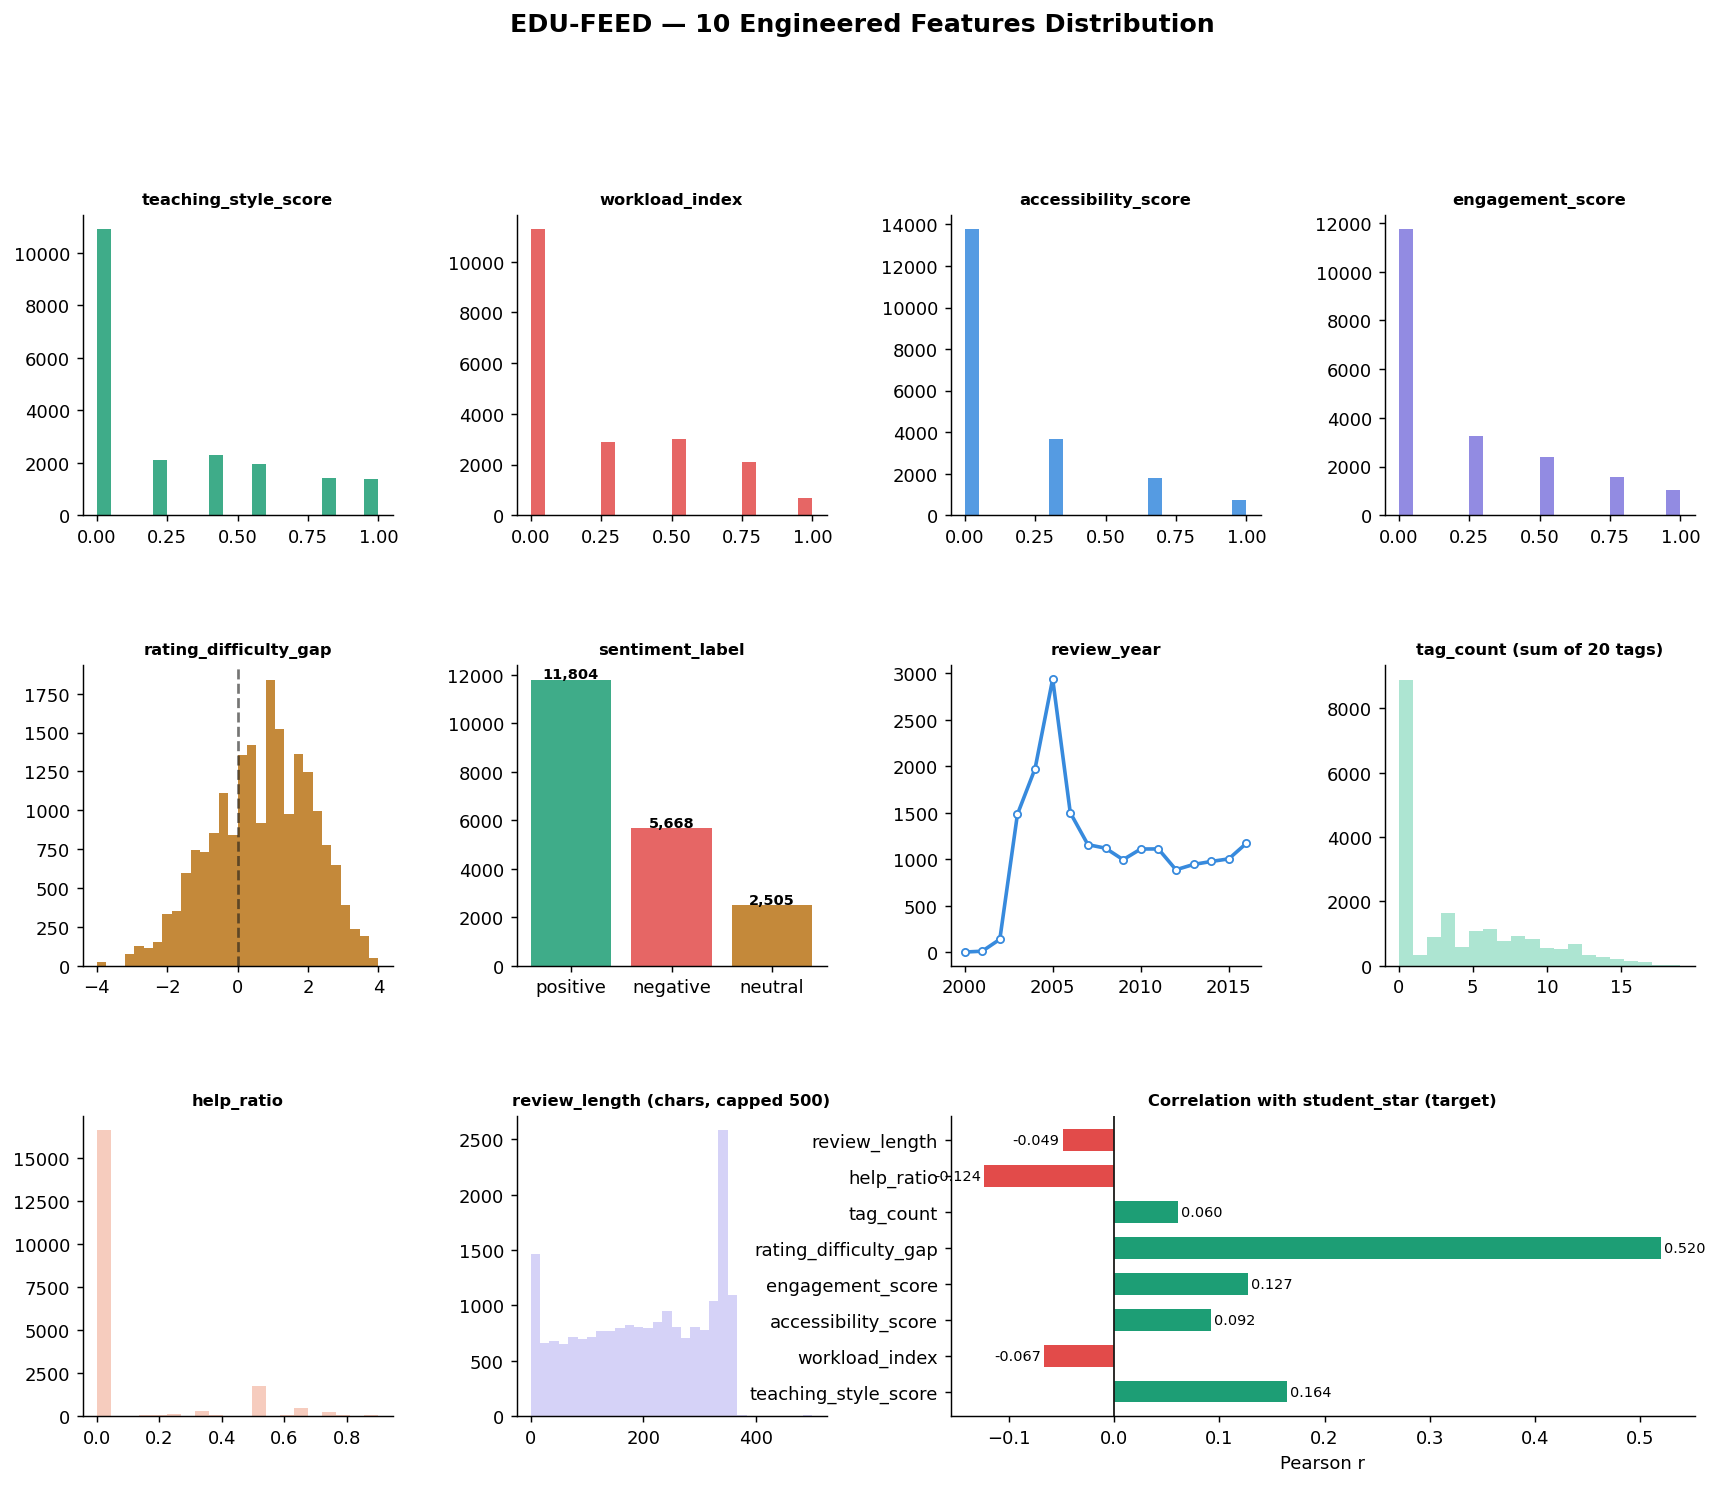

 Saved → charts/05_engineered_features.png


In [96]:
#  FEATURE ENGINEERING VISUALISATIONS
fig = plt.figure(figsize=(16, 12))
fig.suptitle('EDU-FEED — 10 Engineered Features Distribution',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# 1. teaching_style_score
ax1 = fig.add_subplot(gs[0,0])
ax1.hist(df['teaching_style_score'], bins=20, color='#1D9E75', edgecolor='none', alpha=0.85)
ax1.set_title('teaching_style_score', fontweight='bold', fontsize=9)

# 2. workload_index
ax2 = fig.add_subplot(gs[0,1])
ax2.hist(df['workload_index'], bins=20, color='#E24B4A', edgecolor='none', alpha=0.85)
ax2.set_title('workload_index', fontweight='bold', fontsize=9)

# 3. accessibility_score
ax3 = fig.add_subplot(gs[0,2])
ax3.hist(df['accessibility_score'], bins=20, color='#378ADD', edgecolor='none', alpha=0.85)
ax3.set_title('accessibility_score', fontweight='bold', fontsize=9)

# 4. engagement_score
ax4 = fig.add_subplot(gs[0,3])
ax4.hist(df['engagement_score'], bins=20, color='#7F77DD', edgecolor='none', alpha=0.85)
ax4.set_title('engagement_score', fontweight='bold', fontsize=9)

# 5. rating_difficulty_gap
ax5 = fig.add_subplot(gs[1,0])
ax5.hist(df['rating_difficulty_gap'], bins=30, color='#BA7517', edgecolor='none', alpha=0.85)
ax5.axvline(0, color='#1a1a18', linestyle='--', linewidth=1.5, alpha=0.6)
ax5.set_title('rating_difficulty_gap', fontweight='bold', fontsize=9)

# 6. sentiment_label
ax6 = fig.add_subplot(gs[1,1])
sc = df['sentiment_label'].value_counts()
colors6 = {'positive':'#1D9E75','neutral':'#BA7517','negative':'#E24B4A'}
ax6.bar(sc.index, sc.values,
        color=[colors6[x] for x in sc.index], edgecolor='none', alpha=0.85)
ax6.set_title('sentiment_label', fontweight='bold', fontsize=9)
for i,(lbl,val) in enumerate(sc.items()):
    ax6.text(i, val+50, f'{val:,}', ha='center', fontsize=8, fontweight='bold')

# 7. review_year
ax7 = fig.add_subplot(gs[1,2])
yr_counts = df['review_year'].value_counts().sort_index()
yr_counts = yr_counts[(yr_counts.index >= 2000) & (yr_counts.index <= 2016)]
ax7.plot(yr_counts.index, yr_counts.values, color='#378ADD', linewidth=2,
         marker='o', markersize=4, markerfacecolor='white')
ax7.set_title('review_year', fontweight='bold', fontsize=9)

# 8. tag_count
ax8 = fig.add_subplot(gs[1,3])
ax8.hist(df['tag_count'], bins=20, color='#9FE1CB', edgecolor='none', alpha=0.85)
ax8.set_title('tag_count (sum of 20 tags)', fontweight='bold', fontsize=9)

# 9. help_ratio
ax9 = fig.add_subplot(gs[2,0])
ax9.hist(df['help_ratio'], bins=20, color='#F5C4B3', edgecolor='none', alpha=0.85)
ax9.set_title('help_ratio', fontweight='bold', fontsize=9)

# 10. review_length
ax10 = fig.add_subplot(gs[2,1])
ax10.hist(df['review_length'].clip(upper=500), bins=30,
          color='#CECBF6', edgecolor='none', alpha=0.85)
ax10.set_title('review_length (chars, capped 500)', fontweight='bold', fontsize=9)

# Correlation of engineered features with target
ax11 = fig.add_subplot(gs[2,2:])
eng_feats = ['teaching_style_score','workload_index','accessibility_score',
             'engagement_score','rating_difficulty_gap','tag_count',
             'help_ratio','review_length']
corr = df[eng_feats + ['student_star']].corr()['student_star'].drop('student_star')
colors_corr = ['#1D9E75' if v > 0 else '#E24B4A' for v in corr.values]
ax11.barh(corr.index, corr.values, color=colors_corr, height=0.6, edgecolor='none')
ax11.axvline(0, color='#1a1a18', linewidth=1)
ax11.set_title('Correlation with student_star (target)', fontweight='bold', fontsize=9)
ax11.set_xlabel('Pearson r')
for i, v in enumerate(corr.values):
    ax11.text(v + (0.003 if v >= 0 else -0.003), i,
              f'{v:.3f}', va='center', ha='left' if v>=0 else 'right', fontsize=8)

plt.savefig('../charts/05_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → charts/05_engineered_features.png")
